In [33]:
import numpy as np
import matplotlib.pyplot as plt
import heapq
import math
import time

In [34]:
GRID_SIZE = 70

START = (0, 0)
GOAL = (69, 69)

print("Grid size:", GRID_SIZE, "x", GRID_SIZE)
print("Start:", START)
print("Goal:", GOAL)

Grid size: 70 x 70
Start: (0, 0)
Goal: (69, 69)


In [35]:
def generate_obstacles(grid_size, density, start, goal, seed=42):

    np.random.seed(seed)

    grid = np.random.random((grid_size, grid_size)) < density

    # Start and goal must always be free
    grid[start] = False
    grid[goal] = False

    return grid

In [36]:
def plot_grid(grid, start, goal, title):

    plt.figure(figsize=(8, 8))

    plt.imshow(
        grid,
        cmap="gray_r",
        origin="lower"
    )

    plt.scatter(
        start[1],
        start[0],
        marker="o",
        s=100,
        label="Start"
    )

    plt.scatter(
        goal[1],
        goal[0],
        marker="*",
        s=150,
        label="Goal"
    )

    plt.title(title)
    plt.xlabel("X coordinate (km)")
    plt.ylabel("Y coordinate (km)")
    plt.legend()
    plt.grid(False)

    plt.show()

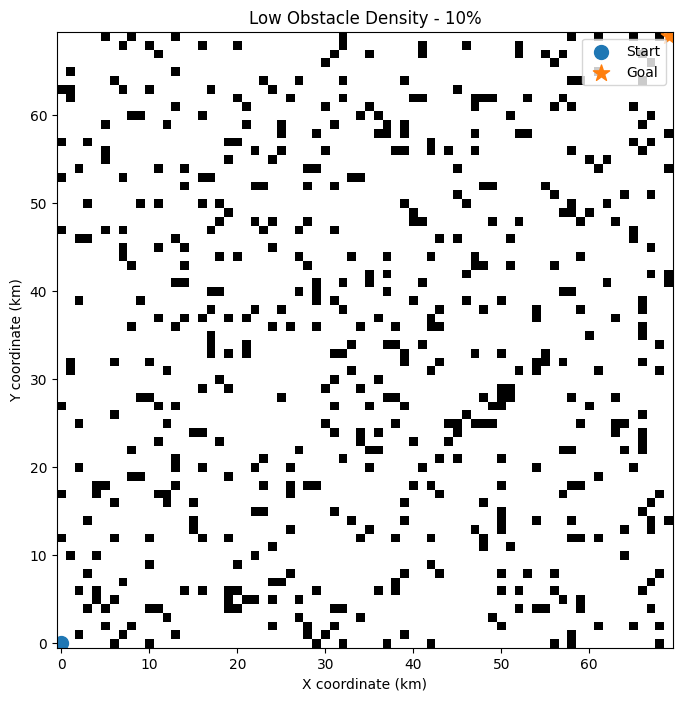

In [37]:
low_grid = generate_obstacles(
    GRID_SIZE,
    0.10,
    START,
    GOAL
)

plot_grid(
    low_grid,
    START,
    GOAL,
    "Low Obstacle Density - 10%"
)

In [38]:
MOVEMENTS = [
    (-1, 0, 1),
    (1, 0, 1),
    (0, -1, 1),
    (0, 1, 1),

    (-1, -1, math.sqrt(2)),
    (-1, 1, math.sqrt(2)),
    (1, -1, math.sqrt(2)),
    (1, 1, math.sqrt(2))
]

In [39]:
def heuristic(node, goal):

    x1, y1 = node
    x2, y2 = goal

    return math.sqrt(
        (x2 - x1) ** 2 +
        (y2 - y1) ** 2
    )

In [40]:
def a_star(grid, start, goal):

    rows, cols = grid.shape

    # Priority queue
    open_list = []

    # g(n) = cost from start to current node
    g_cost = {
        start: 0
    }

    # Store previous node
    parent = {
        start: None
    }

    # Add starting node
    f_start = heuristic(start, goal)

    heapq.heappush(
        open_list,
        (f_start, start)
    )

    # Keep track of expanded nodes
    expanded_nodes = 0

    while open_list:

        current_f, current = heapq.heappop(open_list)

        expanded_nodes += 1

        # Goal reached
        if current == goal:

            path = []

            node = goal

            while node is not None:

                path.append(node)

                node = parent[node]

            path.reverse()

            return path, expanded_nodes

        x, y = current

        # Explore neighbours
        for dx, dy, movement_cost in MOVEMENTS:

            nx = x + dx
            ny = y + dy

            # Check grid boundaries
            if nx < 0 or nx >= rows:
                continue

            if ny < 0 or ny >= cols:
                continue

            # Check obstacle
            if grid[nx, ny]:
                continue

            neighbour = (nx, ny)

            new_g_cost = (
                g_cost[current] +
                movement_cost
            )

            # If a better path is found
            if (
                neighbour not in g_cost
                or new_g_cost < g_cost[neighbour]
            ):

                g_cost[neighbour] = new_g_cost

                parent[neighbour] = current

                f_cost = (
                    new_g_cost +
                    heuristic(neighbour, goal)
                )

                heapq.heappush(
                    open_list,
                    (f_cost, neighbour)
                )

    # No path found
    return None, expanded_nodes

In [41]:
def calculate_path_distance(path):

    if path is None or len(path) < 2:
        return 0

    distance = 0

    for i in range(len(path) - 1):

        x1, y1 = path[i]
        x2, y2 = path[i + 1]

        distance += math.sqrt(
            (x2 - x1) ** 2 +
            (y2 - y1) ** 2
        )

    return distance

In [42]:
def plot_path(grid, path, start, goal, title):

    plt.figure(figsize=(8, 8))

    plt.imshow(
        grid,
        cmap="gray_r",
        origin="lower"
    )

    if path is not None:

        x = [node[1] for node in path]
        y = [node[0] for node in path]

        plt.plot(
            x,
            y,
            linewidth=2,
            label="UGV Path"
        )

    plt.scatter(
        start[1],
        start[0],
        marker="o",
        s=100,
        label="Start"
    )

    plt.scatter(
        goal[1],
        goal[0],
        marker="*",
        s=150,
        label="Goal"
    )

    plt.title(title)

    plt.xlabel("X coordinate (km)")
    plt.ylabel("Y coordinate (km)")

    plt.legend()

    plt.show()

In [43]:
grid = generate_obstacles(
    GRID_SIZE,
    0.10,
    START,
    GOAL,
    seed=42
)

start_time = time.perf_counter()

path, expanded_nodes = a_star(
    grid,
    START,
    GOAL
)

execution_time = time.perf_counter() - start_time

if path is not None:

    path_distance = calculate_path_distance(path)

    print("Path found!")
    print("Path distance:", round(path_distance, 2), "km")
    print("Number of path cells:", len(path))
    print("Nodes expanded:", expanded_nodes)
    print("Execution time:", round(execution_time, 6), "seconds")

else:

    print("No path found.")

Path found!
Path distance: 99.34 km
Number of path cells: 73
Nodes expanded: 531
Execution time: 0.003496 seconds


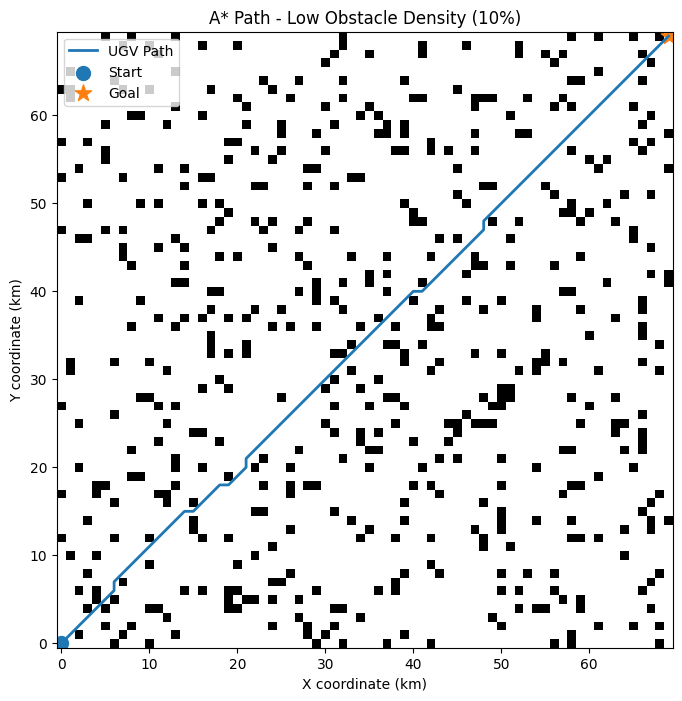

In [44]:
plot_path(
    grid,
    path,
    START,
    GOAL,
    "A* Path - Low Obstacle Density (10%)"
)

In [45]:
densities = {
    "Low": 0.10,
    "Medium": 0.20,
    "High": 0.30
}

results = []

for density_name, density in densities.items():

    grid = generate_obstacles(
        GRID_SIZE,
        density,
        START,
        GOAL,
        seed=42
    )

    start_time = time.perf_counter()

    path, expanded_nodes = a_star(
        grid,
        START,
        GOAL
    )

    execution_time = time.perf_counter() - start_time

    if path is not None:

        distance = calculate_path_distance(path)

        success = "Yes"

        path_length = len(path)

    else:

        distance = None

        success = "No"

        path_length = 0

    results.append({
        "Obstacle Density": density_name,
        "Density (%)": density * 100,
        "Path Found": success,
        "Path Distance (km)": distance,
        "Path Nodes": path_length,
        "Nodes Expanded": expanded_nodes,
        "Execution Time (seconds)": execution_time
    })

In [46]:
import pandas as pd
results_df = pd.DataFrame(results)

display(results_df)

,Obstacle Density,Density (%),Path Found,Path Distance (km),Path Nodes,Nodes Expanded,Execution Time (seconds)
0,Low,10.0,Yes,99.338095,73,531,0.003997
1,Medium,20.0,Yes,101.095454,76,1090,0.006412
2,High,30.0,Yes,101.681241,77,862,0.005799


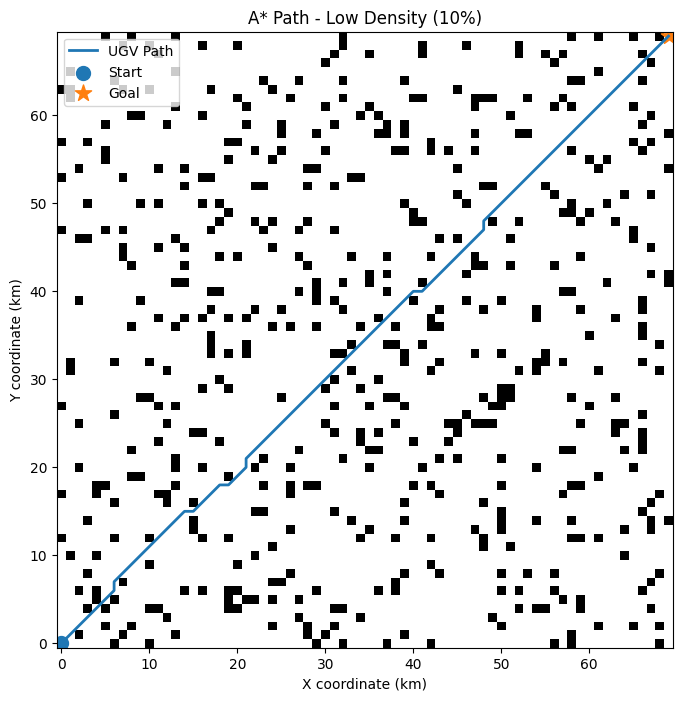

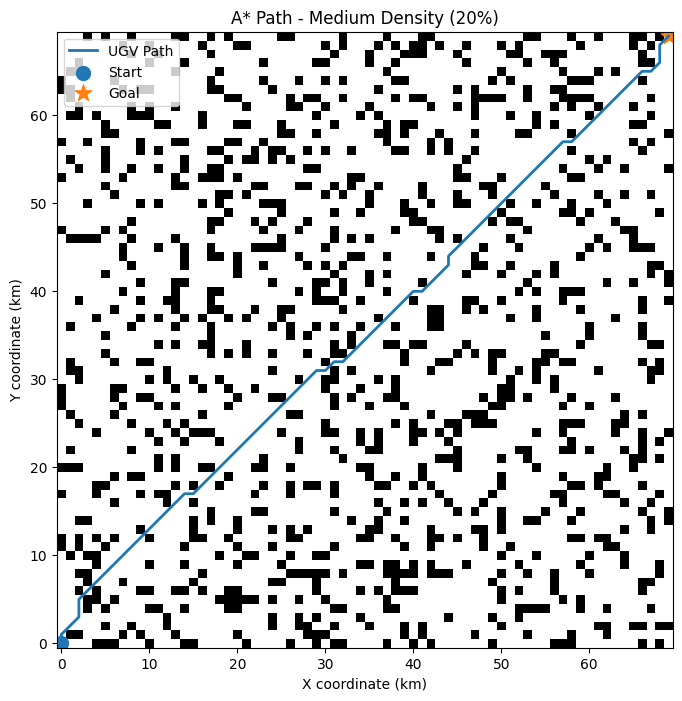

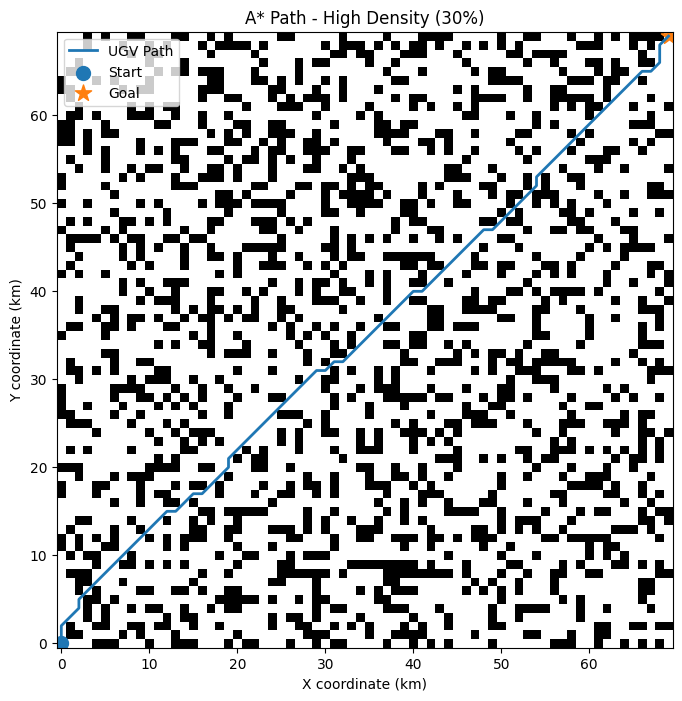

In [47]:
for density_name, density in densities.items():

    grid = generate_obstacles(
        GRID_SIZE,
        density,
        START,
        GOAL,
        seed=42
    )

    path, expanded_nodes = a_star(
        grid,
        START,
        GOAL
    )

    plot_path(
        grid,
        path,
        START,
        GOAL,
        f"A* Path - {density_name} Density ({density*100:.0f}%)"
    )